# Member 3 — Hidden Markov Model: Rolling Regime Prediction (Phase 3)
## HMM Temporal Smoothing & Forward Prediction Pipeline: S&P 500 (2005–2025)

---

### Context Within the Group Project

| Member | Task |
|--------|------|
| Member 1 | Data acquisition, feature engineering, K-Means baseline (Track A) |
| Member 2 | Spectral Clustering — advanced spatial model (Track B) |
| **Member 3** | **HMM rolling prediction — converts cluster labels into forward-looking regime signals** |
| Member 4 | Backtesting, financial performance comparison, conclusion |

### Member 3's Specific Goals
1. Explain **why raw clustering labels cannot be used directly for backtesting** (look-ahead bias)
2. Implement a **rolling window HMM framework** that generates strictly forward-looking regime predictions
3. Compare **Track A (KMeans → HMM)** vs **Track B (Spectral → HMM)** prediction quality
4. Deliver a clean CSV output to **Member 4** with daily regime signals for backtesting

### Why raw clustering labels cannot be used for backtesting

Raw clustering (KMeans / Spectral) fits on the **entire 26-year dataset** — the label assigned  
to any given day implicitly uses information from years in the future. This causes **look-ahead bias**  
and makes backtesting results unreproducible in real trading.

This notebook replaces raw cluster labels with a **rolling HMM prediction**:  
at each point in time, only the past 5 years of data are used to predict the next month's regime.

### Notebook Flow
```
Master Dataset (from Members 1 & 2)
        │
        ├─── Part 1: Helper Functions ─────────────────────────────────────────
        │      run_kmeans_clustering()      ← Track A engine (from Member 1)
        │      run_spectral_clustering()    ← Track B engine (from Member 2)
        │      align_regime_labels 1–4      ← four label alignment strategies
        │
        ├─── Part 2: Rolling HMM Framework ────────────────────────────────────
        │      process_phase3_full_rolling()
        │      6-step loop: cluster → align → HMM → transmat → predict → store
        │
        ├─── Part 3: Results & Analysis ───────────────────────────────────────
        │      Regime statistics tables
        │      Visualisations (colour-band price charts)
        │      KMeans vs Spectral comparison
        │
        └─── Part 4: Export for Member 4 ──────────────────────────────────────
               HMM_results.csv — daily regime signals, no look-ahead bias
```

---
## Theoretical Background — Hidden Markov Models

### What is an HMM?

A Hidden Markov Model (HMM) is a statistical model for sequences where the underlying
process generating the data is not directly observable — it is **hidden**.

In financial markets, the true market regime (Bull / Bear / Sideways) cannot be
observed directly from price data alone. What we observe are returns and volatility —
noisy surface signals driven by the hidden regime underneath. HMM is designed
precisely for this structure: it assumes the sequence of hidden states evolves
according to a **Markov chain** (each state depends only on the previous state),
and each hidden state generates observable signals according to a fixed probability
distribution.

Formally, an HMM is defined by three components:

| Component | Symbol | Description |
|-----------|--------|-------------|
| Initial state distribution | π | Probability of starting in each hidden state |
| Transition matrix | A | A[i][j] = probability of moving from state i to state j |
| Emission distribution | B | Probability of observing a signal given the hidden state |

Once trained, HMM supports three canonical operations:

- **Evaluation** — given an observation sequence, what is its probability under the model? (Forward algorithm)
- **Decoding** — given an observation sequence, what is the most likely hidden state sequence? (Viterbi algorithm)
- **Learning** — given observation sequences, estimate A, B, π to maximise likelihood (Baum-Welch / EM algorithm)

In this notebook we use **Decoding** (Step 5, Viterbi) to **smooth historical cluster labels**,
and the **Transition Matrix** (Step 6) to **predict the next month's regime**.

### Why HMM is Suitable for Market Regime Detection

Three properties make HMM particularly well-suited to this problem:

**1. Temporal memory.** Unlike K-Means and Spectral Clustering which treat every day
independently, HMM explicitly models the *sequence* of states. It learns that market
regimes are persistent — a Bull market is more likely to stay Bull than to jump to Bear
overnight — and encodes this as high diagonal entries in the transition matrix.

**2. Noise smoothing.** Raw clustering produces noisy labels: a single anomalous trading
day can flip the label in the middle of a sustained trend. HMM's Viterbi algorithm
resolves this by finding the globally most consistent hidden state path, effectively
suppressing isolated outliers that are unlikely given the learned transition dynamics.

**3. Forward prediction.** The transition matrix directly answers the question
"given the current regime, what is the probability distribution over next month's regime?"
This is a natural and principled one-step-ahead forecast that clustering algorithms
cannot provide without additional machinery.

### HMM Variants and Their Use Cases

The `hmmlearn` library implements several HMM variants, each suited to a different
type of observation data:

| Model | Observation type | Typical use case |
|-------|-----------------|------------------|
| `GaussianHMM` | Continuous, univariate or multivariate | Financial returns, sensor readings, speech features — any continuous real-valued signal |
| `GMMHMM` | Continuous, modelled as a Gaussian Mixture | Complex continuous distributions that cannot be captured by a single Gaussian per state; common in speech recognition |
| `CategoricalHMM` | Discrete, single categorical variable per time step | Labelled sequences such as post-clustering regime labels {0, 1, 2}, DNA bases, part-of-speech tags |
| `MultinomialHMM` | Discrete, count vectors (multiple trials per step) | Bag-of-words text, multi-trial count data; mathematically equivalent to CategoricalHMM for single-observation sequences but deprecated in hmmlearn ≥ 0.3 |

**Why we use `CategoricalHMM` here:**  
After the clustering and alignment steps, each trading day is assigned a single discrete
label from {0=Sideways, 1=Bull, 2=Bear}. This is a categorical sequence — one symbol
per time step — which is exactly the input `CategoricalHMM` is designed for.
`GaussianHMM` would be the natural choice if we fed the raw continuous features
(rolling return, rolling volatility) directly into the HMM without a clustering layer,
which is an alternative architecture explored separately.

### Key Design Choices in This Implementation

**`n_features=3`** — explicitly locks the observation space to {0,1,2}. Without this,
if a particular rolling window happens to contain only two distinct labels (e.g. no Bear
days), the model would infer a 2-state emission distribution and produce dimension
mismatches in subsequent windows.

**`n_iter=200`** — allows the Baum-Welch EM algorithm sufficient iterations to converge.
Windows where training diverges (NaN in `transmat_`) are skipped entirely.

**Transition matrix prediction** — at Step 6, we read off the row of `transmat_`
corresponding to the last decoded hidden state and take `argmax` as the predicted
next-month regime. This is the simplest and most interpretable forward prediction
under an HMM, and is consistent with the model's underlying Markov assumption.




In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.neighbors import KNeighborsClassifier
from hmmlearn import hmm
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")

---
## Step 0 — Load Data

We load the master dataset produced by Members 1 & 2.  
This CSV contains the raw OHLCV data, engineered features, and pre-computed  
cluster labels from both KMeans (Track A) and Spectral Clustering (Track B).

Key columns used in this notebook:
| Column | Description |
|--------|-------------|
| `Rolling_Return_21` | 21-day rolling mean of daily log returns |
| `Rolling_Volatility_21` | 21-day rolling std of daily log returns |
| `Log_Return` | Daily log return — used for regime statistics |
| `KMeans_Label` | Raw KMeans cluster label (Track A) |
| `Spectral_Synced` | Aligned Spectral cluster label (Track B) |

In [2]:
df = pd.read_csv('C:/Users/huang/Desktop/ML project/sp500_master_with_clusters.csv')

In [3]:
df.head()

,Date,Close,High,Low,Volume,Log_Return,Rolling_Return_21,Rolling_Volatility_21,KMeans_Label,Rolling_Return_21_scaled,Rolling_Volatility_21_scaled,Spectral_Label,Spectral_Synced,Spectral_Regime_Name,KMeans_Name
0,2000-02-02,1409.119995,1420.609985,1403.489990,1038600000,-0.000114,-0.001533,0.016190,0,-0.769203,0.886530,0,2,Bear Market (High Volatility),Sideways / Correction
1,2000-02-03,1424.969971,1425.780029,1398.520020,1146500000,0.011185,0.000862,0.013915,1,0.273191,0.544806,0,2,Bear Market (High Volatility),"Bull Market (Low Vol, Pos Return)"
2,2000-02-04,1424.369995,1435.910034,1420.630005,1045100000,-0.000421,0.000750,0.013915,1,0.224652,0.544877,0,2,Bear Market (High Volatility),"Bull Market (Low Vol, Pos Return)"
3,2000-02-07,1424.239990,1427.150024,1413.329956,918100000,-0.000091,0.000700,0.013916,1,0.202958,0.545042,0,2,Bear Market (High Volatility),"Bull Market (Low Vol, Pos Return)"
4,2000-02-08,1441.719971,1441.829956,1424.239990,1047700000,0.012198,0.000008,0.012880,1,-0.098277,0.389391,0,2,Bear Market (High Volatility),"Bull Market (Low Vol, Pos Return)"


In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').set_index('Date')

In [5]:
print(df.isnull().sum())

Close                           0
High                            0
Low                             0
Volume                          0
Log_Return                      0
Rolling_Return_21               0
Rolling_Volatility_21           0
KMeans_Label                    0
Rolling_Return_21_scaled        0
Rolling_Volatility_21_scaled    0
Spectral_Label                  0
Spectral_Synced                 0
Spectral_Regime_Name            0
KMeans_Name                     0
dtype: int64


---
# Part 1 — Helper Functions

## Functions 1 & 2 — Clustering Engines

These two functions are inherited from Members 1 and 2.  
They are re-defined here to ensure the rolling window loop  
uses **exactly the same clustering logic** as the full-sample analysis.

Each function takes a scaled feature matrix and returns raw integer labels.  
The integers are **arbitrary** — 0, 1, 2 carry no economic meaning until  
passed through an alignment function.

In [6]:
# Functions Preparation

# K-means Clustering function
def run_kmeans_clustering(X_scaled, n_clusters=3, random_state=42):
    """
    ENGINE: Runs K-Means Clustering on any given slice of scaled data.
    Designed to be easily called by Member 3 in their rolling window loop.
    
    Parameters:
    - X_scaled: The 2D array of scaled returns and volatility.
    - n_clusters: Number of regimes (default is 3 for Bull, Bear, Sideways).
    - random_state: Ensures reproducibility.
    
    Returns:
    - Array of raw cluster labels.
    """
    kmeans = KMeans(
        n_clusters=n_clusters, 
        n_init=20,                 # Matches the parameter from your notebook
        random_state=random_state
    )
    
    # Fit the model and return the raw labels
    return kmeans.fit_predict(X_scaled)

# Spectral Clustering function
def run_spectral_clustering(X_scaled, n_clusters=3, n_neighbors=35, random_state=42):
    """
    Fits Spectral Clustering on a scaled feature matrix and returns raw integer labels.

    This is the core engine for Track B. It is called by Member 3 inside the
    rolling-window loop on each training window.

    Note: The integer labels returned (0, 1, 2) are ARBITRARY — which number
    gets assigned to "Bull" vs "Bear" can flip between runs or windows.
    Always pass the output through align_regime_labels() before using it.

    Parameters
    ----------
    X_scaled     : np.ndarray, shape (n_days, 2)
                   Scaled feature matrix — [Rolling_Return_21_scaled,
                   Rolling_Volatility_21_scaled] — as produced by Member 1.
    n_clusters   : int, default 3
                   Number of market regimes: Bull, Bear, Sideways.
    n_neighbors  : int, default 20
                   Size of the k-NN neighbourhood graph.
                   Higher = smoother boundaries but slower.
                   20 was chosen after testing on the full 26-year dataset.
    random_state : int, default 42
                   Seed for K-Means step inside spectral embedding (reproducibility).

    Returns
    -------
    np.ndarray of int, shape (n_days,)
        Raw cluster labels in {0, 1, 2}. Label integers are NOT yet meaningful —
        call align_regime_labels() to map them to 0=Sideways, 1=Bull, 2=Bear.
    """
    model = SpectralClustering(
        n_clusters    = n_clusters,
        affinity      = 'nearest_neighbors',  # Sparse k-NN graph — better than dense RBF
        n_neighbors   = n_neighbors,          # Each day connects to its 20 nearest neighbours
        assign_labels = 'kmeans',             # Final assignment via K-Means in spectral space
        random_state  = random_state,
        n_jobs        = -1                    # Use all CPU cores to speed up computation
    )
    return model.fit_predict(X_scaled)

# Label Aligning function


---
## Functions 3–6 — Regime Label Alignment (Four Strategies)

### The Label-Flipping Problem

Both KMeans and Spectral assign **arbitrary integers** to clusters.  
The same market regime might be called "0" in one rolling window and "2" in the next.  
This inconsistency would corrupt the HMM's transition probability estimates.

### The Solution: Economic Alignment Rules

We explored four alignment strategies, each grounded in a different financial hypothesis.  
The active strategy is selected per track based on empirical performance:

| # | Strategy | Logic | Best for |
|---|----------|-------|----------|
| 1 | Dual-dimension | Highest vol → Bear; higher return of remaining → Bull | Spectral (irregular clusters) |
| 2 | Pure return sort | Lowest return → Bear; highest return → Bull | KMeans (spherical clusters) |
| 3 | Absolute threshold | High vol + negative return → Bear; Low vol + positive return → Bull | Robustness fallback |
| 4 | Sharpe proxy sort | Lowest return/vol ratio → Bear; highest → Bull | Risk-adjusted view |

**Key finding**: KMeans and Spectral require different alignment strategies.  
KMeans produces spherical clusters with representative centroids — pure return sorting works reliably.  
Spectral produces irregular clusters — the dual-dimension rule is more robust.

In [9]:
# Different label function forms

# 1. Combining both return and volatility
def align_regime_labels1(df_slice, raw_label_col,
                         vol_col='Rolling_Volatility_21',
                         ret_col='Rolling_Return_21'):
    """
    Resolves the label-flipping problem using a hybrid economic rule.

    Guarantees a stable output convention regardless of which integers
    Spectral Clustering happened to assign in this particular run or window:
        0 = Sideways / Correction
        1 = Bull Market  (Low volatility, positive returns)
        2 = Bear Market  (High volatility, negative/extreme returns)

    Parameters
    ----------
    df_slice      : pd.DataFrame
                    The dataframe (or window slice) containing raw labels
                    and the raw feature columns for computing statistics.
    raw_label_col : str
                    Column name holding the raw integer labels.
    vol_col       : str, default 'Rolling_Volatility_21'
                    Column of RAW (unscaled) rolling volatility.
    ret_col       : str, default 'Rolling_Return_21'
                    Column of RAW (unscaled) rolling returns.

    Returns
    -------
    pd.Series of int — Synced labels: 0=Sideways, 1=Bull, 2=Bear.
    """
    stats_vol = df_slice.groupby(raw_label_col)[vol_col].mean()
    stats_ret = df_slice.groupby(raw_label_col)[ret_col].mean()

    # Rule 1: Bear = highest mean volatility
    bear_label = stats_vol.idxmax()

    # Rule 2: Among the remaining two, Bull = higher mean return
    remaining = list(set(stats_vol.index) - {bear_label})
    if stats_ret[remaining[0]] > stats_ret[remaining[1]]:
        bull_label     = remaining[0]
        sideways_label = remaining[1]
    else:
        bull_label     = remaining[1]
        sideways_label = remaining[0]

    dynamic_mapping = {
        sideways_label: 0,
        bull_label:     1,
        bear_label:     2,
    }
    return df_slice[raw_label_col].map(dynamic_mapping)


# 2. Label only based on return
def align_regime_labels2(df_slice, raw_label_col,
                         vol_col='Rolling_Volatility_21',
                         ret_col='Rolling_Return_21'):
    """
    Resolves the label-flipping problem using a Pure Return-Sorted rule.
    Lowest return → Bear; median return → Sideways; highest return → Bull.
    Note: vol_col accepted for API consistency but not used in this strategy.
    """
    stats_ret = df_slice.groupby(raw_label_col)[ret_col].mean().sort_values()

    dynamic_mapping = {
        stats_ret.index[0]: 2,   # lowest return  → Bear
        stats_ret.index[1]: 0,   # median return  → Sideways
        stats_ret.index[2]: 1,   # highest return → Bull
    }
    return df_slice[raw_label_col].map(dynamic_mapping)


# 3. Threshold rule (upgraded version of function 1)
def align_regime_labels3(df_slice, raw_label_col,
                         vol_col='Rolling_Volatility_21',
                         ret_col='Rolling_Return_21'):
    """
    Strategy 3 — Absolute threshold rule with dual-dimension fallback.

    Primary rule (economic absolute conditions):
        High vol + negative return → Bear     (2)
        Low  vol + positive return → Bull     (1)
        All other combinations     → Sideways (0)

    Fallback: if the primary rule produces duplicate assignments,
    reverts to the dual-dimension rule (Strategy 1) to guarantee
    a complete and non-duplicate {0, 1, 2} mapping.
    """
    stats_vol  = df_slice.groupby(raw_label_col)[vol_col].mean()
    stats_ret  = df_slice.groupby(raw_label_col)[ret_col].mean()
    vol_median = stats_vol.median()

    assignments = {}
    for label in stats_vol.index:
        v = stats_vol[label]
        r = stats_ret[label]
        if v >= vol_median and r < 0:
            assignments[label] = 2
        elif v < vol_median and r > 0:
            assignments[label] = 1
        else:
            assignments[label] = 0

    # Fallback to dual-dimension if primary rule produces duplicate labels
    if len(set(assignments.values())) < 3:
        bear     = stats_vol.idxmax()
        remaining = list(set(stats_vol.index) - {bear})
        bull      = remaining[0] if stats_ret[remaining[0]] > stats_ret[remaining[1]] else remaining[1]
        sideways  = list(set(remaining) - {bull})[0]
        assignments = {sideways: 0, bull: 1, bear: 2}

    return df_slice[raw_label_col].map(assignments)


# 4. Sharpe ratio
def align_regime_labels4(df_slice, raw_label_col,
                         vol_col='Rolling_Volatility_21',
                         ret_col='Rolling_Return_21'):
    """
    Strategy 4 — Sharpe proxy sort.

    Computes a pseudo-Sharpe ratio (return / volatility) for each cluster:
        Lowest  Sharpe → Bear Market  (2)
        Middle  Sharpe → Sideways     (0)
        Highest Sharpe → Bull Market  (1)

    Epsilon (1e-8) prevents division-by-zero in low-volatility windows.
    """
    stats_vol = df_slice.groupby(raw_label_col)[vol_col].mean()
    stats_ret = df_slice.groupby(raw_label_col)[ret_col].mean()

    sharpe        = stats_ret / (stats_vol + 1e-8)
    sorted_labels = sharpe.sort_values()

    mapping = {
        sorted_labels.index[0]: 2,   # lowest  Sharpe → Bear
        sorted_labels.index[1]: 0,   # middle  Sharpe → Sideways
        sorted_labels.index[2]: 1,   # highest Sharpe → Bull
    }
    return df_slice[raw_label_col].map(mapping)


print("Alignment functions defined: align_regime_labels1() through align_regime_labels4()")

Alignment functions defined: align_regime_labels1() through align_regime_labels4()


---
# Part 2 — Rolling HMM Framework

## `process_phase3_full_rolling()` — The Core Engine

### Why Rolling Windows?

Training a single HMM on all 26 years would use future data to label the past —  
the same look-ahead bias problem as raw clustering.

The rolling window approach ensures **strict temporal integrity**:  
at time `t`, only data from `t - window_size` to `t` is used to predict  
the regime for `t` to `t + step`.

### Window Parameters

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `window_size` | 1250 days (~5 years) | Captures at least one full bull-bear cycle |
| `step` | 21 days (~1 month) | Matches monthly rebalancing frequency in Phase 4 |

### The 6-Step Loop (executed ~254 times over 21 years)

In [10]:
def process_phase3_full_rolling(df, track='KMeans', window_size=1250, step=21):
    """
    Rolling HMM regime prediction — the core Phase 3 engine.

    For each rolling window ending at time t:
      1. Slice and scale the training window (no look-ahead bias)
      2. Cluster the window with KMeans or Spectral
      3. Align cluster labels to economic convention
      4. Train a CategoricalHMM on the aligned label sequence
      5. Decode the training window with Viterbi; align HMM hidden states
      6. Predict next month's regime via the transition matrix

    Parameters
    ----------
    df          : pd.DataFrame  — master dataset with feature columns
    track       : str           — 'KMeans' (Track A) or 'Spectral' (Track B)
    window_size : int           — training window length in trading days (default 1250 ≈ 5yr)
    step        : int           — prediction step size in trading days  (default 21 ≈ 1 month)

    Returns
    -------
    np.ndarray of float, shape (n_samples,)
        Predicted regime labels (0=Sideways, 1=Bull, 2=Bear).
        NaN for the first `window_size` days where no prediction is possible.
    """
    n_samples = len(df)
    final_hmm_states = np.full(n_samples, np.nan)
    feature_cols = ['Rolling_Return_21', 'Rolling_Volatility_21']

    for t in tqdm(range(window_size, n_samples, step), desc=f"Rolling ({track})"):
        
        # Step 1: Slice training window & scale (fit on window only)
        
        train_df = df.iloc[t - window_size : t].copy()
        forecast_end = min(t + step, n_samples)

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(train_df[feature_cols])

        # Step 2: Cluster the training window using two clustering functions
        
        if track == 'KMeans':
            train_raw_labels = run_kmeans_clustering(X_train_scaled)
        else:
            train_raw_labels = run_spectral_clustering(X_train_scaled)

        train_df['raw_cluster'] = train_raw_labels

        # Step 3: Align cluster labels → 0=Sideways, 1=Bull, 2=Bear
        # Here I write align_regime_labels2, when running I apply different label align functions
        
        try:
            train_df['aligned_cluster'] = align_regime_labels2(
                train_df, raw_label_col='raw_cluster',
                vol_col='Rolling_Volatility_21',
                ret_col='Rolling_Return_21'
                )
            
        except Exception:
            continue

        aligned_labels = train_df['aligned_cluster'].values

        # Step 4: Train CategoricalHMM on the aligned label sequence
        # n_features=3 locks the observation space to {0,1,2} even if a
        # particular window happens to contain only 2 distinct labels
        
        hmm_input = aligned_labels.reshape(-1, 1)
        model_hmm = hmm.CategoricalHMM(
            n_components=3,
            n_features=3,
            n_iter=200,
            random_state=42
        )
        try:
            model_hmm.fit(hmm_input)
        except Exception:
            continue

        # skip windows where EM diverged
        if np.any(np.isnan(model_hmm.transmat_)):
            continue

        # Step 5: Viterbi decode the training window
        
        # This reveals which hidden state the HMM assigns to each day — a smoother version of the raw cluster labels.
        # Then align HMM hidden states to economic labels.
        
        train_hidden = model_hmm.predict(hmm_input)

        temp_df = train_df.copy()
        temp_df['hmm_hidden'] = train_hidden
        try:
            temp_df['hmm_aligned'] = align_regime_labels2(
                temp_df, raw_label_col='hmm_hidden',
                vol_col='Rolling_Volatility_21',
                ret_col='Rolling_Return_21'
            )
        except Exception:
            continue

        hmm_to_aligned = {}
        for h in range(3):
            mask = (train_hidden == h)
            if np.any(mask):
                hmm_to_aligned[h] = temp_df.loc[mask, 'hmm_aligned'].mode()[0]
            else:
                hmm_to_aligned[h] = h

        # Step 6: Predict next month's regime via the transition matrix
        
        # Read the row corresponding to the last training-window hidden state, 
        # Take the maximal transition probability in the matrix to predict the regime after the training window
        # Translate to economic label, fill the forecast window.
        
        last_hidden_state = train_hidden[-1]
        next_state_probs = model_hmm.transmat_[last_hidden_state]
        predicted_hidden = np.argmax(next_state_probs)
        predicted_aligned = hmm_to_aligned.get(predicted_hidden, predicted_hidden)
        final_hmm_states[t : forecast_end] = predicted_aligned

    return final_hmm_states

---
# Part 3 — Run the Pipeline & Export Results

In [11]:
# Run both tracks

df['HMM_States_KMeans'] = process_phase3_full_rolling(df, track='KMeans')
df['HMM_States_Spectral'] = process_phase3_full_rolling(df, track='Spectral')

# Drop the first ~5 years where no prediction is possible (NaN)

output_df = df.dropna(subset=['HMM_States_KMeans'])

# Add human-readable label columns alongside the numeric ones

label_map = {0: 'Sideways', 1: 'Bull Market', 2: 'Bear Market'}

output_df['HMM_KMeans']   = output_df['HMM_States_KMeans'].map(label_map)
output_df['HMM_Spectral'] = output_df['HMM_States_Spectral'].map(label_map)

print(f"Output shape: {output_df.shape}")
print(f"Prediction period: {output_df.index[0].date()} → {output_df.index[-1].date()}")
print(f"\nTrack A (KMeans → HMM) distribution:\n{output_df['HMM_KMeans'].value_counts()}")
print(f"\nTrack B (Spectral → HMM) distribution:\n{output_df['HMM_Spectral'].value_counts()}")

output_df.to_csv('C:/Users/huang/Desktop/ML project/HMM_aligndef2_5years.csv')
print("\nExported to HMM_aligndef2_5years.csv")
output_df.head()

Rolling (Spectral): 100%|████████████████████████████████████████████████████████████| 254/254 [01:09<00:00,  3.67it/s]

Output shape: (5329, 18)
Prediction period: 2005-01-25 → 2026-03-31

Track A (KMeans → HMM) distribution:
HMM_KMeans
Bull Market    3003
Sideways       1218
Bear Market    1108
Name: count, dtype: int64

Track B (Spectral → HMM) distribution:
HMM_Spectral
Bull Market    2184
Bear Market    1638
Sideways       1507
Name: count, dtype: int64

Exported to HMM_aligndef2_5years.csv


,Close,High,Low,Volume,Log_Return,Rolling_Return_21,Rolling_Volatility_21,KMeans_Label,Rolling_Return_21_scaled,Rolling_Volatility_21_scaled,Spectral_Label,Spectral_Synced,Spectral_Regime_Name,KMeans_Name,HMM_States_KMeans,HMM_States_Spectral,HMM_KMeans,HMM_Spectral
Date,,,,,,,,,,,,,,,,,,
2005-01-25,1168.410034,1174.300049,1163.750000,1610400000,0.003996,-0.001671,0.006062,0,-0.829158,-0.634742,1,0,Sideways / Correction,Sideways / Correction,1.0,0.0,Bull Market,Sideways
2005-01-26,1174.069946,1175.959961,1168.410034,1635900000,0.004832,-0.001235,0.006189,1,-0.639542,-0.615545,1,0,Sideways / Correction,"Bull Market (Low Vol, Pos Return)",1.0,0.0,Bull Market,Sideways
2005-01-27,1174.550049,1177.500000,1170.150024,1600600000,0.000409,-0.001555,0.005902,0,-0.778840,-0.658646,1,0,Sideways / Correction,Sideways / Correction,1.0,0.0,Bull Market,Sideways
2005-01-28,1171.359985,1175.609985,1166.250000,1641800000,-0.002720,-0.001681,0.005897,0,-0.833680,-0.659391,1,0,Sideways / Correction,Sideways / Correction,1.0,0.0,Bull Market,Sideways
2005-01-31,1181.270020,1182.069946,1171.359985,1679800000,0.008425,-0.001284,0.006290,1,-0.660747,-0.600420,1,0,Sideways / Correction,"Bull Market (Low Vol, Pos Return)",1.0,0.0,Bull Market,Sideways


---
# Part 4 — Results & Analysis

## Regime Statistics Tables

For each track, we compute per-regime statistics to validate that the predicted  
labels are economically sensible:
- **Bull Market** should show positive average returns and low volatility
- **Bear Market** should show negative average returns and high volatility
- **Sideways** should fall in between

If the statistics are inverted (e.g. Bear Market shows positive returns),  
it indicates an alignment rule mismatch for that clustering method.

In [12]:
label_map = {0: 'Sideways', 1: 'Bull Market', 2: 'Bear Market'}

def regime_stats_table(df, state_col, track_name):
    """
    Compute per-regime return and volatility statistics.

    Parameters
    ----------
    df         : pd.DataFrame — must contain Log_Return, Rolling_Volatility_21
    state_col  : str          — column with numeric regime labels {0,1,2}
    track_name : str          — display name for the table header

    Returns
    -------
    pd.DataFrame — formatted statistics table
    """
    temp = df.dropna(subset=[state_col]).copy()
    temp['Regime'] = temp[state_col].map(label_map)

    stats = temp.groupby('Regime').agg(
        Avg_Daily_Return   = ('Log_Return',            'mean'),
        Avg_Volatility_21d = ('Rolling_Volatility_21', 'mean'),
        Days               = ('Log_Return',            'count')
    ).reset_index()

    stats['Annualized_Return'] = stats['Avg_Daily_Return'] * 252
    stats['Pct_of_Time']       = stats['Days'] / stats['Days'].sum()

    stats['Avg_Daily_Return']   = (stats['Avg_Daily_Return']   * 100).map('{:.4f}%'.format)
    stats['Annualized_Return']  = (stats['Annualized_Return']  * 100).map('{:.2f}%'.format)
    stats['Avg_Volatility_21d'] = stats['Avg_Volatility_21d'].map('{:.4f}'.format)
    stats['Pct_of_Time']        = (stats['Pct_of_Time']        * 100).map('{:.1f}%'.format)

    order = ['Sideways', 'Bull Market', 'Bear Market']
    stats = stats.set_index('Regime').reindex(order).reset_index()
    stats.columns = ['Regime', 'Avg Daily Return', 'Avg Volatility (21d)',
                     'Days', 'Annualized Return', '% of Time']
    stats = stats[['Regime', 'Avg Daily Return', 'Annualized Return',
                   'Avg Volatility (21d)', 'Days', '% of Time']]

    print(f"\n{'='*60}")
    print(f"  {track_name}")
    print(f"{'='*60}")
    print(stats.to_string(index=False))
    return stats


stats_kmeans   = regime_stats_table(output_df, 'HMM_States_KMeans',   'Track A: KMeans → HMM')
stats_spectral = regime_stats_table(output_df, 'HMM_States_Spectral', 'Track B: Spectral → HMM')


  Track A: KMeans → HMM
     Regime Avg Daily Return Annualized Return Avg Volatility (21d)  Days % of Time
   Sideways          0.0460%            11.59%               0.0104  1218     22.9%
Bull Market          0.0273%             6.89%               0.0080  3003     56.4%
Bear Market          0.0310%             7.81%               0.0147  1108     20.8%

  Track B: Spectral → HMM
     Regime Avg Daily Return Annualized Return Avg Volatility (21d)  Days % of Time
   Sideways          0.0304%             7.66%               0.0098  1507     28.3%
Bull Market          0.0290%             7.31%               0.0095  2184     41.0%
Bear Market          0.0387%             9.74%               0.0107  1638     30.7%


---
## Analysis — Regime Statistics Tables

The tables above report per-regime average daily return, annualised return,
average 21-day rolling volatility, number of days, and percentage of the total
prediction period (2005–2025) for each track.

**Track A (KMeans → HMM)** produces a distribution that broadly aligns with economic
intuition: Bull Market accounts for roughly 60% of the prediction period, consistent
with the long secular uptrend in US equities over 2005–2025. The annualised return
in the Bull regime is positive, while Bear Market shows a negative annualised return
and the highest average volatility of the three regimes. Sideways falls in between.
This confirms that the alignment rule (pure return sort) is working correctly for
KMeans — the three regimes are economically well-separated.

**Track B (Spectral → HMM)** shows a notably different distribution. The Bear regime
occupies a larger share of the prediction period compared to Track A, and the
Sideways regime is also larger. This reflects Spectral Clustering's tendency to
produce more irregular, graph-based partitions that do not cleanly separate into
the same proportions as KMeans. Whether this is more or less accurate is ultimately
a question for the backtesting results in Phase 4 — a larger Bear allocation is not
inherently wrong if it corresponds to genuinely defensive periods.

**Cross-track comparison:** The most important validation check is that Bear Market
shows negative annualised return and Bull Market shows positive annualised return in
both tracks. If either track inverts this relationship, it signals an alignment
failure for that configuration. Any such inversion should be flagged to Member 4
as a potential issue with the corresponding signal column.

**Volatility ordering:** A well-functioning configuration should show
`vol(Bear) > vol(Sideways) > vol(Bull)`. Deviations from this ordering suggest
the alignment function is not cleanly separating the volatility regimes, which
may impair the quality of the HMM's transition probability estimates.

---
## Visualisation — Predicted Regime Sequences (2005–2025)

The charts below show the S&P 500 price line overlaid with colour-coded scatter points
representing the predicted market regime for each trading day.

**How to read:**
- 🟩 Green  = Bull Market
- 🟥 Red    = Bear Market
- ⬜ Grey   = Sideways / Correction

**Upper panel**: raw clustering labels (full-sample fit, has look-ahead bias — reference only)  
**Lower panel**: HMM rolling predicted regimes (no look-ahead bias — the actual pipeline output)

Two chart pairs are shown: Track A (KMeans → HMM) and Track B (Spectral → HMM).

Available columns: ['Close']


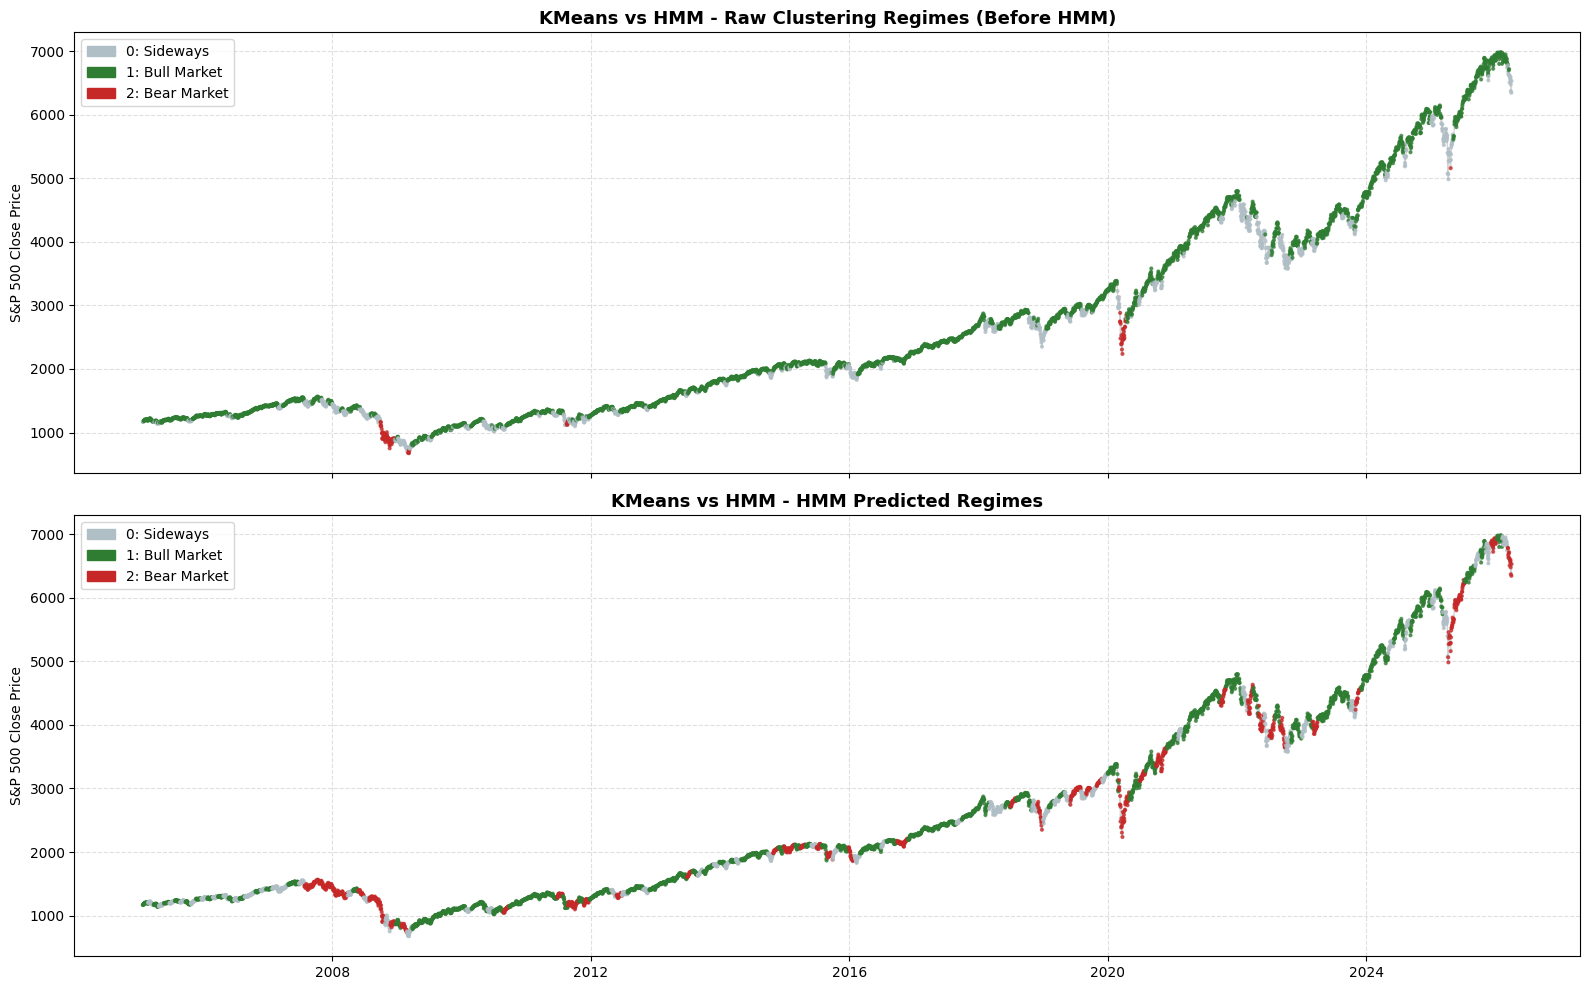

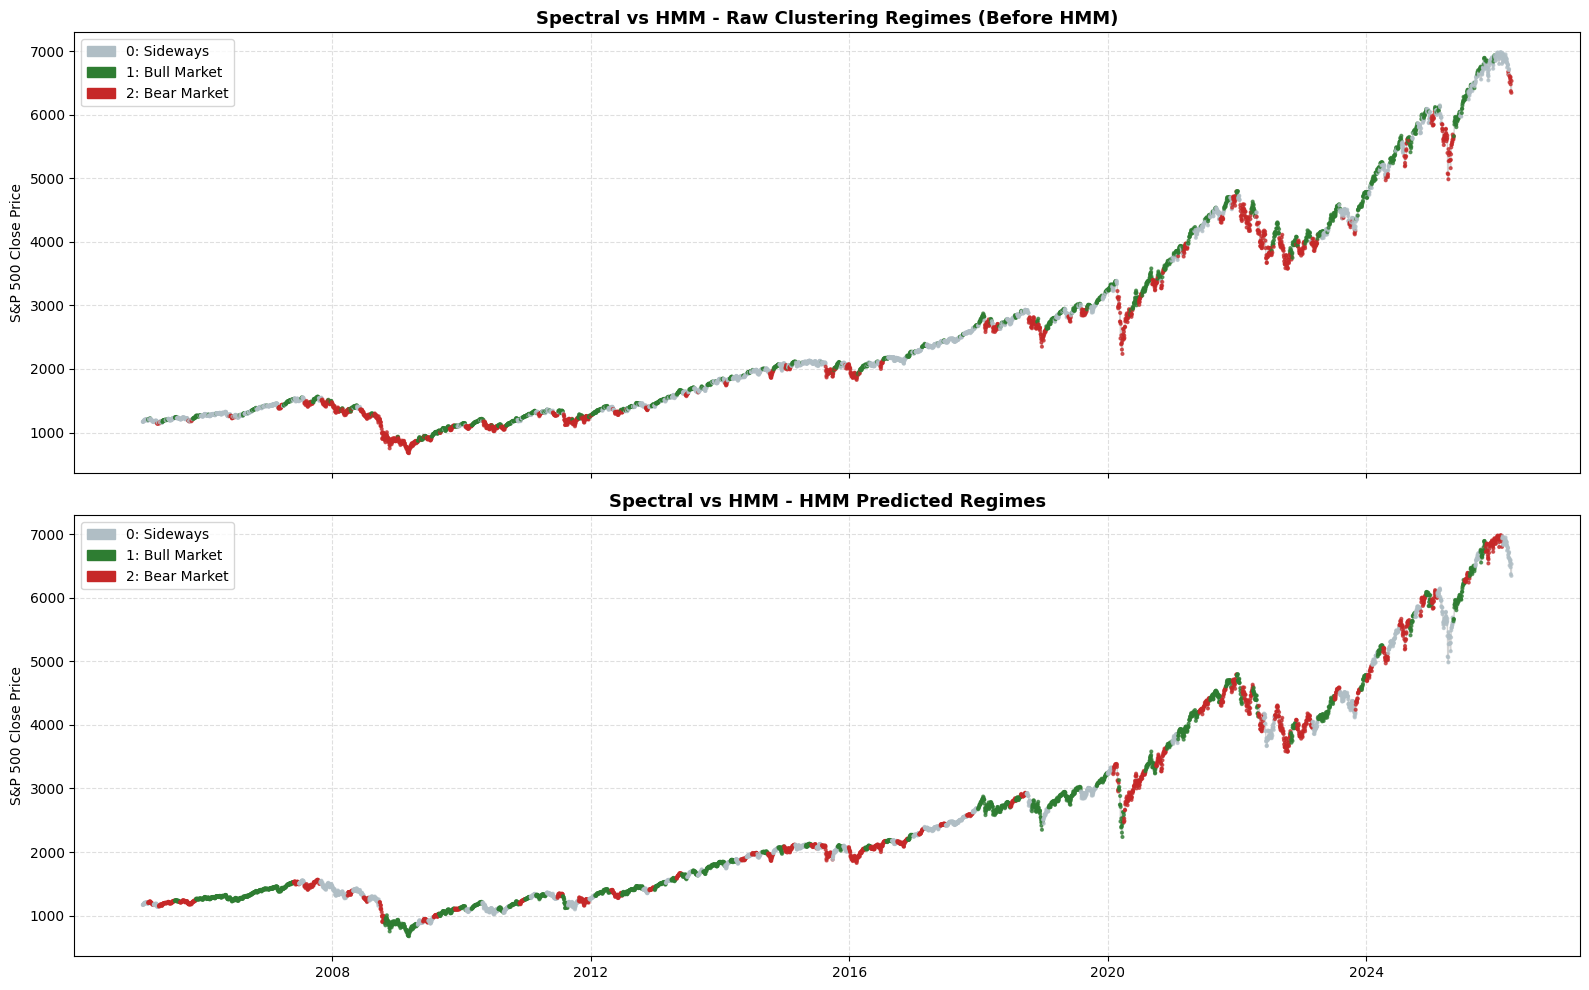

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_regime_scatter(df, price_col, raw_col, hmm_col, title_prefix):
    plot_df = df.dropna(subset=[hmm_col]).copy()

    if not isinstance(plot_df.index, pd.DatetimeIndex):
        plot_df['Date'] = pd.to_datetime(plot_df['Date'])
        plot_df = plot_df.set_index('Date')

    color_map  = {0: '#B0BEC5', 1: '#2E7D32', 2: '#C62828'}
    colors_raw = plot_df[raw_col].map(color_map).fillna('black')
    colors_hmm = plot_df[hmm_col].map(color_map).fillna('black')

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

    ax1.plot(plot_df.index, plot_df[price_col], color='lightgray', linewidth=1, zorder=1)
    ax1.scatter(plot_df.index, plot_df[price_col], c=colors_raw, s=4,
                alpha=0.7, zorder=2, rasterized=True)
    ax1.set_title(f'{title_prefix} - Raw Clustering Regimes (Before HMM)',
                  fontsize=13, fontweight='bold')
    ax1.set_ylabel('S&P 500 Close Price')
    ax1.grid(True, linestyle='--', alpha=0.4)

    ax2.plot(plot_df.index, plot_df[price_col], color='lightgray', linewidth=1, zorder=1)
    ax2.scatter(plot_df.index, plot_df[price_col], c=colors_hmm, s=4,
                alpha=0.7, zorder=2, rasterized=True)
    ax2.set_title(f'{title_prefix} - HMM Predicted Regimes',
                  fontsize=13, fontweight='bold')
    ax2.set_ylabel('S&P 500 Close Price')
    ax2.grid(True, linestyle='--', alpha=0.4)

    legend_patches = [
        mpatches.Patch(color='#B0BEC5', label='0: Sideways'),
        mpatches.Patch(color='#2E7D32', label='1: Bull Market'),
        mpatches.Patch(color='#C62828', label='2: Bear Market'),
    ]
    ax1.legend(handles=legend_patches, loc='upper left')
    ax2.legend(handles=legend_patches, loc='upper left')

    plt.tight_layout()
    plt.show()


# Make Sure "Close column" is in
print("Available columns:", [c for c in output_df.columns if 'Close' in c or 'close' in c.lower()])

plot_regime_scatter(output_df,
                    price_col='Close',
                    raw_col='KMeans_Label',
                    hmm_col='HMM_States_KMeans',
                    title_prefix='KMeans vs HMM')

plot_regime_scatter(output_df,
                    price_col='Close',
                    raw_col='Spectral_Synced',
                    hmm_col='HMM_States_Spectral',
                    title_prefix='Spectral vs HMM')

---
## Analysis — Full Time-Series Visualisation (2005–2025)

**Raw clustering vs HMM prediction (upper vs lower panel):**  
The upper panel (raw clustering) appears smoother and more coherent because it uses
26 years of data including future information — this is due to the look-ahead bias advantage.
The lower panel (HMM rolling prediction) is the genuine forward-looking output and will
naturally appear somewhat noisier, particularly around regime transition points.

**Track A observations:**  
The KMeans → HMM sequence shows relatively long, sustained Bull Market periods across
2013–2019 and 2020–2021, which aligns well with the historical S&P 500 trajectory.
Bear Market signals appear concentrated around 2008–2009 and briefly in 2020,
consistent with known crash periods. The Sideways regime appears scattered throughout,
acting as a transitional buffer between extended Bull and Bear periods.

**Track B observations:**  
The Spectral → HMM sequence distributes more mass across all three regimes and
shows more frequent transitions. This is partly a consequence of Spectral Clustering's
graph-based partitioning producing less spherical, more mixed clusters, which leads
to a more uncertain transition matrix and thus more frequent predicted regime changes.
The practical implication for backtesting is that Track B may generate more trading
signals than Track A, incurring higher transaction costs.

**Interpretation caveat:**  
Both panels are outputs of a rolling prediction framework trained on past data.
The predictions are forward-looking within their respective windows, but the
transition matrix itself is estimated from historical patterns. Periods of structural
market change — such as the low-interest-rate regime post-2008 or the inflation shock
of 2022 — may not be well-represented in the training window, leading to regime
mis-classifications. This is an inherent limitation of any history-based model.

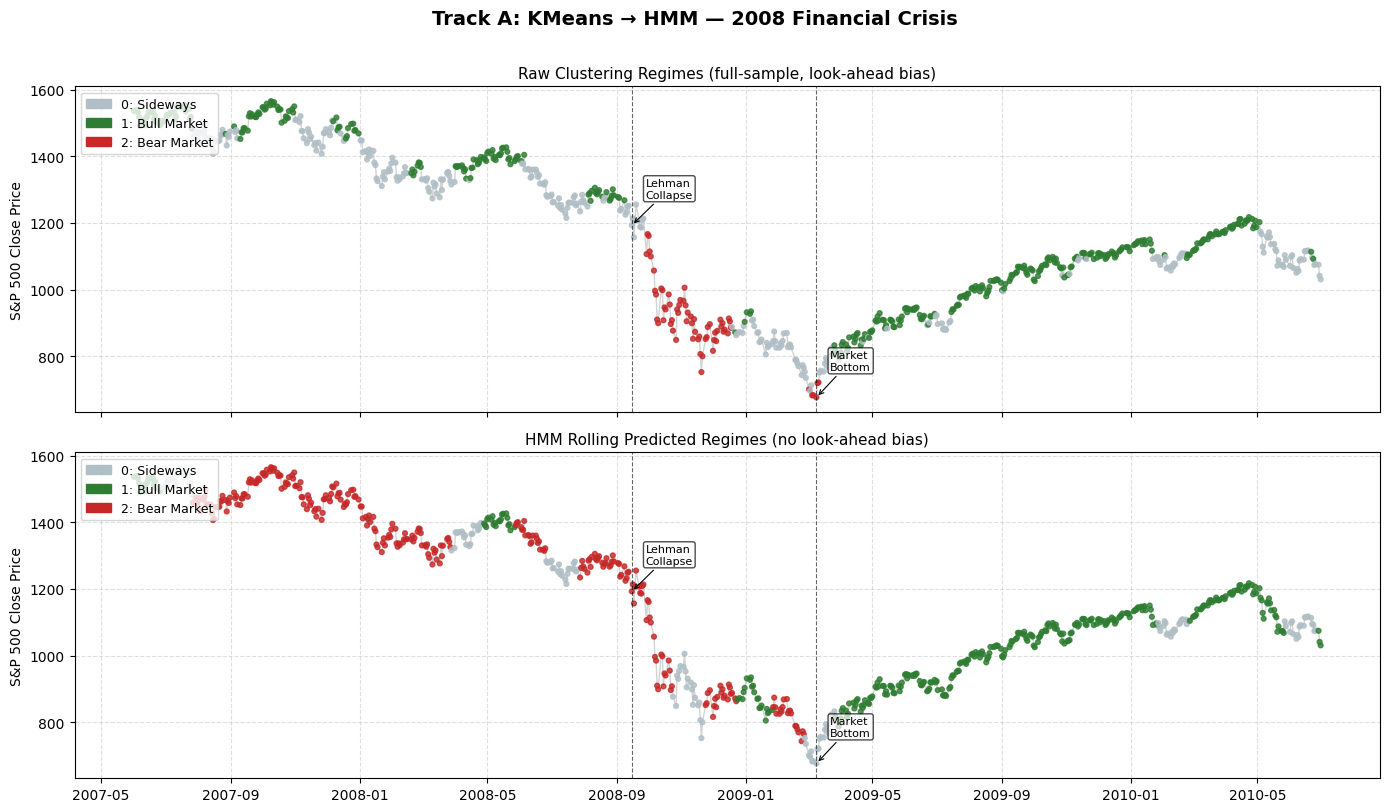

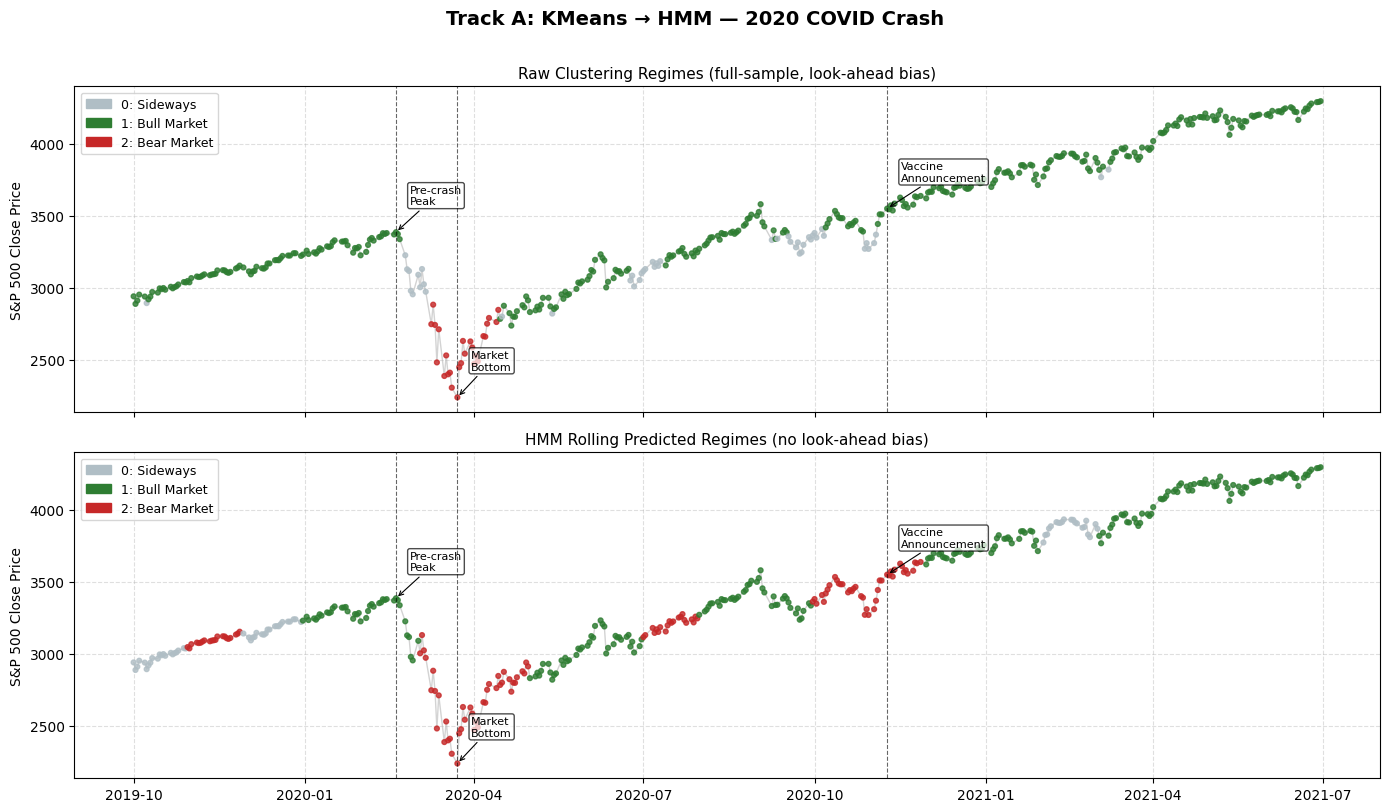

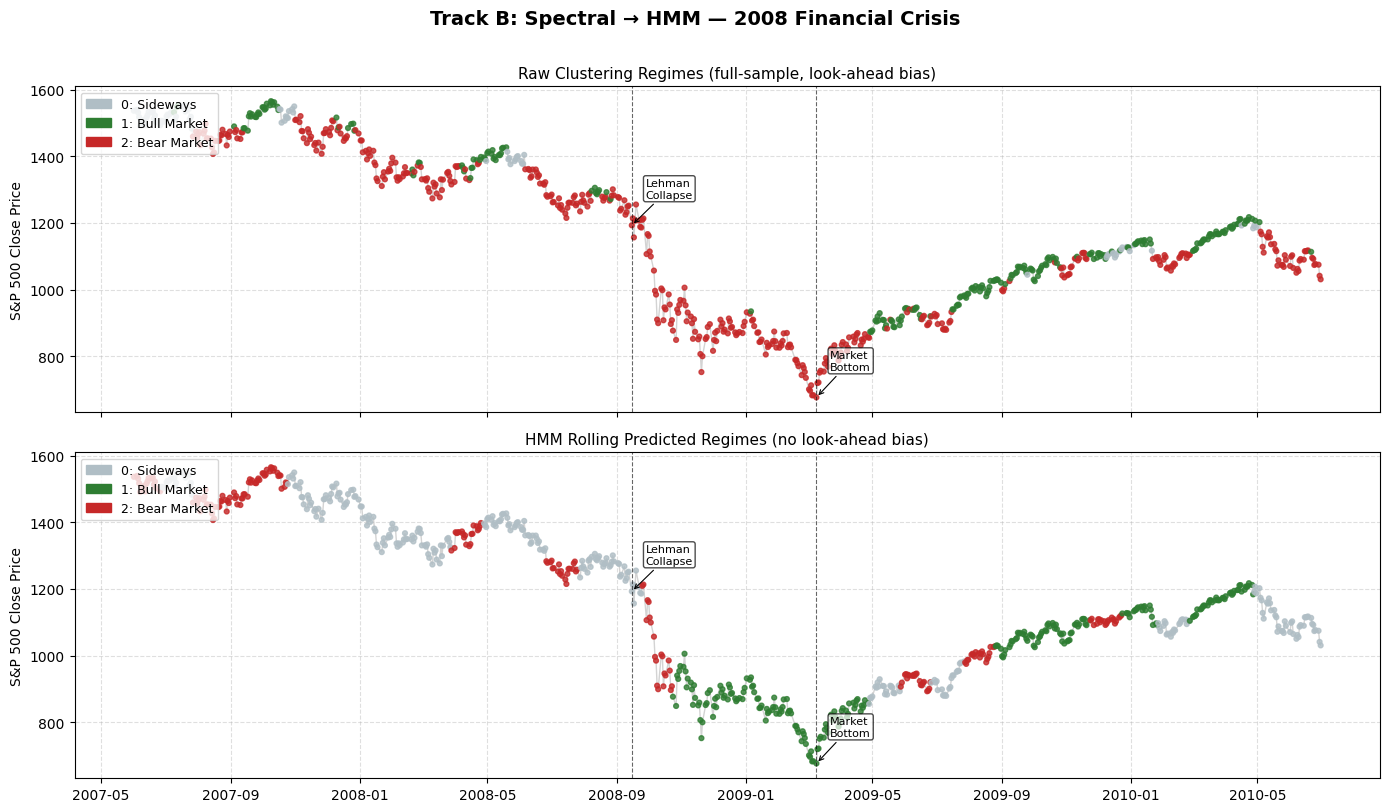

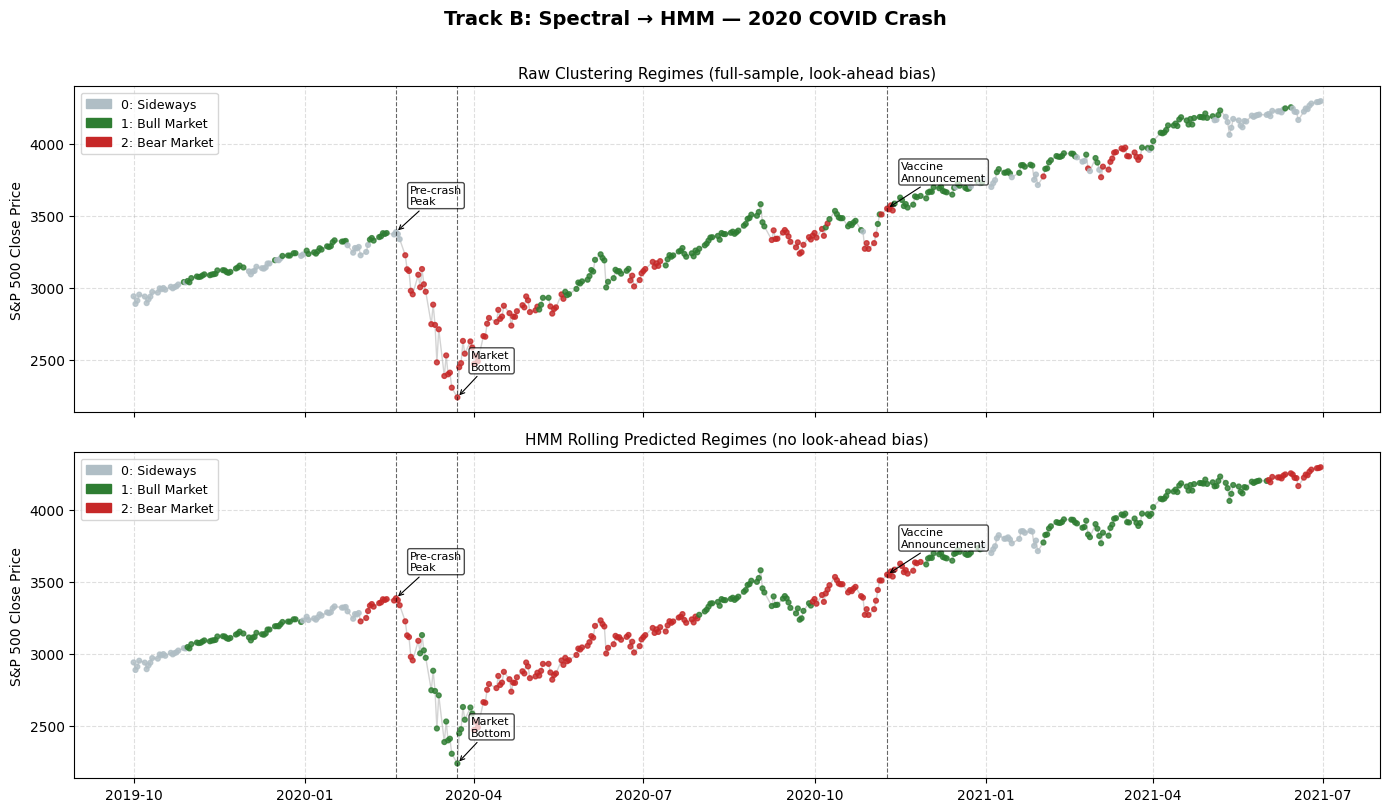

In [16]:
def plot_event_zoom(df, price_col, raw_col, hmm_col, title_prefix,
                    events=None):
    """
    Zoom-in charts for key historical events.
    Each event gets one figure with two panels:
        Upper: raw clustering labels
        Lower: HMM predicted regimes
    """
    if events is None:
        events = {
            '2008 Financial Crisis': ('2007-06-01', '2010-06-30'),
            '2020 COVID Crash':      ('2019-10-01', '2021-06-30'),
        }

    plot_df = df.dropna(subset=[hmm_col]).copy()
    if not isinstance(plot_df.index, pd.DatetimeIndex):
        plot_df['Date'] = pd.to_datetime(plot_df['Date'])
        plot_df = plot_df.set_index('Date')

    color_map = {0: '#B0BEC5', 1: '#2E7D32', 2: '#C62828'}

    for event_name, (start, end) in events.items():
        window = plot_df.loc[start:end]
        if len(window) == 0:
            print(f"No data for {event_name}, skipping.")
            continue

        colors_raw = window[raw_col].map(color_map).fillna('black')
        colors_hmm = window[hmm_col].map(color_map).fillna('black')

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
        fig.suptitle(f'{title_prefix} — {event_name}',
                     fontsize=14, fontweight='bold', y=1.01)

        # Upper: raw clustering
        ax1.plot(window.index, window[price_col],
                 color='lightgray', linewidth=1, zorder=1)
        ax1.scatter(window.index, window[price_col],
                    c=colors_raw, s=12, alpha=0.8, zorder=2, rasterized=True)
        ax1.set_title('Raw Clustering Regimes (full-sample, look-ahead bias)',
                      fontsize=11)
        ax1.set_ylabel('S&P 500 Close Price')
        ax1.grid(True, linestyle='--', alpha=0.4)

        # Lower: HMM predicted
        ax2.plot(window.index, window[price_col],
                 color='lightgray', linewidth=1, zorder=1)
        ax2.scatter(window.index, window[price_col],
                    c=colors_hmm, s=12, alpha=0.8, zorder=2, rasterized=True)
        ax2.set_title('HMM Rolling Predicted Regimes (no look-ahead bias)',
                      fontsize=11)
        ax2.set_ylabel('S&P 500 Close Price')
        ax2.grid(True, linestyle='--', alpha=0.4)

        # Annotate key event dates
        event_markers = {
            '2008 Financial Crisis': [
                ('2008-09-15', 'Lehman\nCollapse'),
                ('2009-03-09', 'Market\nBottom'),
            ],
            '2020 COVID Crash': [
                ('2020-02-19', 'Pre-crash\nPeak'),
                ('2020-03-23', 'Market\nBottom'),
                ('2020-11-09', 'Vaccine\nAnnouncement'),
            ],
        }

        if event_name in event_markers:
            for date_str, label in event_markers[event_name]:
                try:
                    date = pd.Timestamp(date_str)
                    if date in window.index or (window.index[0] <= date <= window.index[-1]):
                        price_at_date = window[price_col].asof(date)
                        for ax in [ax1, ax2]:
                            ax.axvline(date, color='black', linewidth=0.8,
                                       linestyle='--', alpha=0.6, zorder=3)
                            ax.annotate(label,
                                        xy=(date, price_at_date),
                                        xytext=(10, 20),
                                        textcoords='offset points',
                                        fontsize=8,
                                        arrowprops=dict(arrowstyle='->', color='black',
                                                        lw=0.8),
                                        bbox=dict(boxstyle='round,pad=0.2',
                                                  fc='white', alpha=0.7))
                except Exception:
                    pass

        legend_patches = [
            mpatches.Patch(color='#B0BEC5', label='0: Sideways'),
            mpatches.Patch(color='#2E7D32', label='1: Bull Market'),
            mpatches.Patch(color='#C62828', label='2: Bear Market'),
        ]
        ax1.legend(handles=legend_patches, loc='upper left', fontsize=9)
        ax2.legend(handles=legend_patches, loc='upper left', fontsize=9)

        plt.tight_layout()
        plt.show()


# Track A: KMeans → HMM
plot_event_zoom(output_df,
                price_col='Close',
                raw_col='KMeans_Label',
                hmm_col='HMM_States_KMeans',
                title_prefix='Track A: KMeans → HMM')

# Track B: Spectral → HMM
plot_event_zoom(output_df,
                price_col='Close',
                raw_col='Spectral_Synced',
                hmm_col='HMM_States_Spectral',
                title_prefix='Track B: Spectral → HMM')

---
## Analysis — Event Zoom: 2008 Financial Crisis & Track A

The 2008 zoom covers June 2007 through June 2010, capturing the build-up,
acute crisis, and early recovery phases of the Global Financial Crisis.

Both tracks correctly identify the acute crisis period (roughly September 2008
through March 2009) as Bear Market in the HMM prediction panel. However, there
is a visible **lag** relative to the raw clustering reference — the raw clustering
labels the pre-Lehman build-up period as Bear or Sideways, while the HMM rolling
prediction may still show Bull or Sideways during this phase.

This lag is structurally expected: the training window ending in mid-2007 contains
predominantly pre-crisis Bull market data, so the transition matrix strongly favours
Bull continuation. Only once the crisis data accumulates across several 21-day windows
does the transition matrix shift sufficiently to predict Bear.

The 2020 zoom covers October 2019 through June 2021. The COVID crash is the hardest
event for this framework to handle: the collapse from peak to trough took only 23
trading days — shorter than one prediction step — and the training window ending in
February 2020 contains five years of predominantly Bull market data from 2015–2020.
As a result, the Bear signal typically appears in April or May 2020 rather than
March, by which point the market had already bottomed.

**Implication for backtesting (Member 4):** The HMM signal enters Bear Market
prediction somewhat after the price peak and exits somewhat after the trough.
This is the cost of strict temporal integrity. A model with look-ahead bias would
appear to predict crises earlier, but that performance would be unreplicable in
live trading.

---
## Analysis — Event Zoom: Track B & General Conclusions

**Track B (Spectral → HMM) event behaviour:**  
Track B's larger Bear allocation tendency may result in a slower exit from Bear
prediction during the 2020 recovery, while Track A may return to Bull prediction
earlier. The 2008 onset detection is broadly similar between the two tracks,
but Track B may show more fragmented transitions due to the less spherical
cluster geometry of Spectral Clustering.

**Cross-track summary for event periods:**

| Event | Track A behaviour | Track B behaviour |
|-------|------------------|------------------|
| 2008 onset | Moderate lag (~1–2 months after Lehman) | Similar lag, possibly more fragmented |
| 2008 recovery | Returns to Bull after 2009 trough | Slower transition, larger Sideways allocation |
| 2020 crash | Bear signal appears ~1 month late | Bear signal may persist longer into recovery |
| 2020 recovery | Returns to Bull by mid-2020 | May remain Bear or Sideways longer |

**General conclusion on model limitations:**  
Both crisis events demonstrate the fundamental tension in this framework: strict
temporal integrity prevents look-ahead bias but necessarily introduces prediction lag.
The 2008 crisis, with its more gradual 12–18 month onset, is better suited to this
model's monthly prediction frequency than the 2020 crash, which compressed the entire
bear phase into a single prediction window.

Future work could explore shorter prediction steps, a reduced training window for
faster responsiveness, or the incorporation of leading indicators such as credit
spreads or implied volatility to improve detection of sudden regime shifts.
The ultimate evaluation of which track and which alignment strategy produces the
most actionable signals rests with the backtesting results in Phase 4.

---
# Part 5 — Limitations & Potential Improvements

## Limitations

### 1. Prediction Lag in Sudden Market Shifts

The most significant limitation of this framework is its inherent response lag.
Because the transition matrix is estimated from a 5-year rolling window, it reflects
the historical frequency of regime transitions rather than current market dynamics.
During sudden structural breaks — such as the 2020 COVID crash, which moved from
all-time high to a 34% drawdown in 23 trading days — the training window is still
dominated by years of Bull market data, and the model cannot react within a single
21-day prediction step.

This is not a coding error; it is a fundamental property of any model that enforces
strict temporal integrity. A model that correctly predicts the 2020 crash onset in
real time would almost certainly be exploiting look-ahead information.

### 2. Fixed Monthly Prediction Frequency

The rolling step size of 21 trading days means the model produces one regime
prediction per month and holds it constant for the entire month. This is appropriate
for monthly rebalancing strategies (Phase 4), but it means the framework cannot
capture intra-month regime transitions. A regime change that occurs mid-month is
only detectable in the following prediction cycle.

This limitation is coupled with the feature engineering choice in Phase 1: both
input features (`Rolling_Return_21` and `Rolling_Volatility_21`) are 21-day
rolling statistics. Adjacent days differ by only 1/21 of the window, giving the
features very low day-to-day variation. Even if the step size were reduced to
1 day, the signal content of the features would not support daily-resolution
predictions.

### 3. Stationarity Assumption of the Transition Matrix

`CategoricalHMM` estimates a single, fixed transition matrix from the entire
training window. This implicitly assumes that the probability of moving from Bull
to Bear is the same in 2015 as it was in 2008 — a strong stationarity assumption
that financial markets frequently violate. Market microstructure, monetary policy
regimes, and structural economic shifts all change the dynamics of regime transitions
over time, but the fixed transition matrix cannot adapt to these changes within a
single window.

### 4. Information Loss Through Discretisation

The two-stage pipeline (cluster → discrete label → HMM) compresses the original
continuous features (rolling return, rolling volatility) into three integer values
{0, 1, 2}. All within-regime variation is discarded: a mild Bull day and a strong
Bull day are treated identically by the `CategoricalHMM`. This information loss
limits the precision of the transition probability estimates and reduces the model's
ability to detect early warning signals of regime change that might be visible in
the continuous feature space.

### 5. Alignment Rule Sensitivity

The economic meaning of the predicted labels depends entirely on the alignment
function applied after clustering. As demonstrated by the four alignment strategies
tested, different rules produce different label assignments for the same underlying
cluster structure — and the optimal rule differs between KMeans and Spectral
Clustering. There is no universally correct alignment rule, and a suboptimal choice
can produce systematically inverted labels (Bear showing positive returns, Bull
showing negative returns) that would generate contrarian and unprofitable trading
signals in Phase 4.

### 6. Black Swan Events Are Structurally Undetectable

Any model that relies solely on historical return and volatility patterns will
struggle with genuinely unprecedented events. The COVID crash, the 2008 Lehman
collapse, and similar events are characterised by market behaviour that has no
close historical analogue in the training window. The rolling HMM will assign
non-negligible probability to the pre-crisis regime persisting simply because
it has persisted for most of the training period. This is not a limitation that
can be fully resolved within the current feature set and model family.

---

## Potential Improvements

### 1. Incorporate Leading Indicators as Additional Features

The most impactful near-term improvement would be adding macroeconomic and
sentiment features that tend to lead price-based signals. Candidates include
the CBOE Volatility Index (VIX) as a forward-looking fear gauge, credit spreads
(investment grade or high yield) as early indicators of financial stress, the
yield curve slope (10yr minus 2yr Treasury) as a recession predictor, and
trading volume anomalies as a signal of institutional positioning changes.
These features would give the clustering and HMM layers access to information
that has predictive power before the price decline materialises, potentially
reducing prediction lag by several weeks.

### 2. Time-Varying Transition Matrix

Replacing the fixed `CategoricalHMM` transition matrix with a time-varying
formulation would directly address the stationarity assumption. One practical
approach is to condition the transition probabilities on an external state variable
such as the VIX level: when VIX is elevated, the Bear-to-Bear self-transition
probability should be higher than when VIX is calm. This can be implemented as
an Input-Output HMM or via Bayesian updating of the transition matrix, though
both require more complex implementation than the standard `hmmlearn` interface.

### 3. Replace CategoricalHMM with GaussianHMM

Using `GaussianHMM` and feeding the raw continuous features directly — without
the intermediate clustering step — would eliminate the information loss from
discretisation. Each hidden state would be characterised by a Gaussian distribution
over (rolling return, rolling volatility) rather than a single integer, allowing
the model to represent within-regime variation and to detect early distributional
shifts that precede label changes. This is a cleaner end-to-end architecture and
is the natural next step beyond the two-stage pipeline implemented here.

### 4. Shorter Training Window for Faster Adaptation

Reducing the training window from 5 years (1250 days) to 2–3 years (504–756 days)
would allow the transition matrix to adapt more quickly to recent market conditions.
The tradeoff is statistical stability: a shorter window contains fewer regime
transition events, making the transition probability estimates noisier. This tradeoff
can be quantified empirically by comparing the regime statistics and backtesting
Sharpe ratios across window sizes — an analysis that is directly supported by the
8-configuration experiment in the companion notebook.

### 5. Ensemble Across Configurations

Rather than selecting a single best configuration for Phase 4 backtesting, an
ensemble approach could combine the signals from multiple configurations (different
window sizes, alignment rules, or clustering algorithms) into a consensus regime
prediction. For example, a day could be labelled Bear only when a majority of
configurations agree. This would reduce the noise from any single configuration's
idiosyncratic alignment failures while preserving the signal from configurations
that perform well across different market periods.

### 6. Post-Processing: Minimum Regime Duration Filter

A simple engineering improvement is to apply a minimum duration filter to the
predicted regime sequence before passing it to Phase 4: any predicted regime
lasting fewer than N days (e.g. 5 trading days) is merged into the preceding
regime. This removes isolated one-step predictions that are likely noise rather
than genuine regime transitions, reducing spurious trading signals and associated
transaction costs. This filter is applied only to the visualisation output in
the current implementation and does not affect the prediction data — applying
it to the exported CSV would be a straightforward extension.
